# COE 592

##  ASSIGNMENT 1


**Description:**

  In this hands-on assignment, you will apply the concepts of feature detection, description and matching methods using OpenCV2 library, and re-assemble an image's slices to match the original image's snapshot

**Deliverables**

  * Completed version of this notebook, renamed to `COE592-Assg1-<Student1_ID>-<Student2_ID>.ipynb`
  * A short report following the below outline:
    * Problem Statement
    * Solution Design and Methodology
      * Describe your proposed solution using a flowchart and psuedocode
    * Experiments and Results
      * Try your solution on some sample images, and include the snapshots of intermediate results, the final re-assembled image, and similarity scores
      * Refer to the hands-on tutorial to see how to implement matching and to show matching results
    * Team details: Names and IDs of the team
  * The original images you used in your work
  

**Submission Instructions:**

Please submit all the deliverables on Blackboard (as individual files and not as a zip/rar archive)


**Credits:**

Prepared by Dr. Abdul Jabbar Siddiqui


In [1]:
import numpy as np
import cv2
import random
import matplotlib.pyplot as plt
# from google.colab.patches import cv2_imshow

In [2]:
# to mount your google drive (requires Google log in)
# Alternatively, use the "Mount Drive" button from the "Files" tab on the left menu bars
# from google.colab import drive
# drive.mount('/drive')

In [3]:
# Copy and save path to your images directory in mypath
# mypath = '/content/drive/MyDrive/COE595/colab-teaching/'

# Load Images

In [4]:

# Read the larger scene image in which you want to find the query_img object in scene_img
# scene_img = cv2.imread(mypath+'/T3_drone.jpg')
img_link = r"./drone.jpg"
scene_img = cv2.imread(img_link)


# Slice and Shuffle Scene Image

In [5]:
# Convert images to grayscale (recommended for ease of using opencv feature descriptors like SIFT, ORB, SURF, etc.)

scene_img_bw = cv2.cvtColor(scene_img, cv2.COLOR_BGR2GRAY)


# Function to take a scene_img and split it into multiple slices, returns a shuffled list of slices
def slice_and_shuffle(inimg, doShuffle=True):
  M = inimg.shape[0] // 5
  N = inimg.shape[1] // 5
  # M=5, N=5, to make 25 tiles from a given inimg

  tiles = [inimg[x:x+M,y:y+N] for x in range(0,inimg.shape[0],M) for y in range(0,inimg.shape[1],N)]

  random.shuffle(tiles)

  return tiles

slices_list = slice_and_shuffle(scene_img_bw) # You cannot manipulate this list, but you may manipulate scene_img_bw if needed

# Tasks to do:
  * Complete the function `reassemble_slices(...)`: using feature detection and matching, re-assemble the slices in `slices_list` to produce the `reassembled_img`
    
    * Hint: select an appropriate feature detector/descriptor and use feature matching to match each slice with the respective region in `scene_img_bw`
    * Note:
      * your solution must not be based on prior knowledge of the slicing sequence or shuffling order. The re-assembling should be based on matching
      * Your solution must have a verification step to deal with "confused" matches and correct those
      * Your solution must not be specific to one image, it should be generic enough to work with different images



In [6]:
# YOUR TASK TO DO

def reassemble_slices(slist = slices_list, orig_img = scene_img_bw):

  # Your code here...

  ## SIFT Implementation
  reassembled_img = np.zeros_like(orig_img) # dummy init.

  ## 5x5 grid.
  M = orig_img.shape[0] // 5
  N = orig_img.shape[1] // 5

  ## Instatiate SIFT detector
  sift = cv2.SIFT_create(nfeatures=1000)
  scene_kp, scene_des = sift.detectAndCompute(orig_img, None)

  ## Brute Force Matcher
  matcher = cv2.BFMatcher()

  # Hint: you may use each slice as a query_img
  for query_img in slist:
    query_kp, query_des = sift.detectAndCompute(query_img, None)
    if query_des is None or len(query_des) <2:
      continue

    matches = matcher.knnMatch(query_des, scene_des, k=2)

    good_matches = list()
    for m, n in matches:
      if m.distance < .75 * n.distance:
        good_matches.append(m)

    if len(good_matches) <2:
      continue

    query_pts = np.float32([query_kp[m.queryIdx].pt for m in good_matches])
    scene_pts = np.float32([scene_kp[m.trainIdx].pt for m in good_matches])

    offsets = scene_pts - query_pts
    median_x = np.median(offsets[:, 0])
    median_y = np.median(offsets[:, 1])

    start_col = int(round(median_x /N)*N)
    start_row = int(round(median_y /M)*M)

    # Now make the image.
    if 0 <= start_row < orig_img.shape[0] and 0 <= start_col < orig_img.shape[1]:
      reassembled_img[start_row:start_row+M, start_col:start_col+N] = query_img

  # reassembled_img =  # your final reassembled image should be returned as reassembled_img, should be an opencv format

  return reassembled_img



reassembled_img = reassemble_slices(slices_list, scene_img_bw)

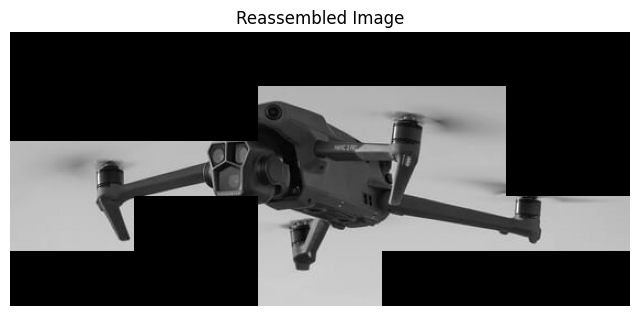

In [7]:
plt.figure(figsize=(8, 8))
plt.imshow(reassembled_img, cmap='gray')
plt.title("Reassembled Image")
plt.axis('off')
plt.show()

# Testing

  * Compare your `reassembled_img` with `scene_img_bw`
  * Use scikit-image library's Structural Similarity Index (SSIM) to compare
    * Read https://scikit-image.org/docs/stable/api/skimage.metrics#skimage.metrics.structural_similarity for more info

In [8]:
# This function compares scene_img_bw and reassembled_img to check for correctness in re-assembling

from skimage.metrics import structural_similarity

def check_reassembly(prod=reassembled_img, orig=scene_img_bw):

  # Use scikit-image library's Structural Similarity Index (SSIM) to compare
  # Read https://scikit-image.org/docs/stable/api/skimage.metrics#skimage.metrics.structural_similarity for more info

  score = structural_similarity(reassembled_img, scene_img_bw)


  return score

In [9]:
# You may test your reassembled_img's similarity to the original scene_img_bw

print(check_reassembly(reassembled_img, scene_img_bw))

0.42281611016619364
